# Week 10B: Model Validation with MiniLearn Metrics

Comprehensive model validation using Stratified K-Fold cross-validation, GridSearchCV hyperparameter tuning, and **MiniLearn metrics**.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression as SKLogisticRegression
from sklearn.tree import DecisionTreeClassifier as SKDecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier as SKKNeighborsClassifier
from sklearn.naive_bayes import GaussianNB as SKGaussianNB
from sklearn.svm import SVC as SKSupportVectorMachine
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from minilearn.model_selection import StratifiedKFold as MLStratifiedKFold, cross_validate

from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.metrics import accuracy_score as sk_accuracy, precision_score as sk_precision
from sklearn.metrics import recall_score as sk_recall, f1_score as sk_f1
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

print("Imports successful!")

Imports successful!


## Data Preparation

In [2]:
# Load features
features_df = pd.read_csv('../data/features.csv')
print(f"Features shape: {features_df.shape}")
print("First few rows:")
print(features_df.head())

# Extract features and labels
numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
X = features_df[numeric_cols].to_numpy()
y = features_df['emotion'].to_numpy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Unique emotions: {np.unique(y)}")

Features shape: (1440, 384)
First few rows:
                                            filepath  \
0  C:\Users\wblut\Documents\My Projects\Python\CS...   
1  C:\Users\wblut\Documents\My Projects\Python\CS...   
2  C:\Users\wblut\Documents\My Projects\Python\CS...   
3  C:\Users\wblut\Documents\My Projects\Python\CS...   
4  C:\Users\wblut\Documents\My Projects\Python\CS...   

                   filename  modality_code  vocal_channel_code  emotion_code  \
0  03-01-01-01-01-01-01.wav              3                   1             1   
1  03-01-01-01-01-01-02.wav              3                   1             1   
2  03-01-01-01-01-01-03.wav              3                   1             1   
3  03-01-01-01-01-01-04.wav              3                   1             1   
4  03-01-01-01-01-01-05.wav              3                   1             1   

   intensity_code  statement_code  repetition  actor_id    modality  ...  \
0               1               1           1         1  audio

In [3]:
# Split data: 80/20 stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")

Training set size: 1152
Test set size: 288


## Section 1: Verify MiniLearn Metrics Match sklearn

In [4]:
# Train a simple model for metric comparison
test_model = SKLogisticRegression(random_state=42, max_iter=500)
test_model.fit(X_train_scaled, y_train)
y_pred_test = test_model.predict(X_test_scaled)

print("Comparing MiniLearn vs scikit-learn Metrics:")
print("="*70)

# Accuracy
ml_acc = accuracy_score(y_test, y_pred_test)
sk_acc = sk_accuracy(y_test, y_pred_test)
print("\nAccuracy:")
print(f"  MiniLearn: {ml_acc:.6f}")
print(f"  sklearn:   {sk_acc:.6f}")
print(f"  Match: {np.isclose(ml_acc, sk_acc)}")

# Precision (macro)
ml_prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
sk_prec = sk_precision(y_test, y_pred_test, average='macro', zero_division=0)
print("\nPrecision (macro):")
print(f"  MiniLearn: {ml_prec:.6f}")
print(f"  sklearn:   {sk_prec:.6f}")
print(f"  Match: {np.isclose(ml_prec, sk_prec)}")

# Recall (macro)
ml_recall = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
sk_recall = sk_recall(y_test, y_pred_test, average='macro', zero_division=0)
print("\nRecall (macro):")
print(f"  MiniLearn: {ml_recall:.6f}")
print(f"  sklearn:   {sk_recall:.6f}")
print(f"  Match: {np.isclose(ml_recall, sk_recall)}")

# F1 (macro)
ml_f1 = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
sk_f1_val = sk_f1(y_test, y_pred_test, average='macro', zero_division=0)
print("\nF1 Score (macro):")
print(f"  MiniLearn: {ml_f1:.6f}")
print(f"  sklearn:   {sk_f1_val:.6f}")
print(f"  Match: {np.isclose(ml_f1, sk_f1_val)}")

# Confusion Matrix
ml_cm = confusion_matrix(y_test, y_pred_test)
sk_cm = sk_confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix:")
print(f"  MiniLearn shape: {ml_cm.shape}")
print(f"  sklearn shape:   {sk_cm.shape}")
print(f"  All values match: {np.array_equal(ml_cm, sk_cm)}")

print("\n" + "="*70)
print("✓ MiniLearn metrics verified! All results match sklearn.")

Comparing MiniLearn vs scikit-learn Metrics:

Accuracy:
  MiniLearn: 0.854167
  sklearn:   0.854167
  Match: True

Precision (macro):
  MiniLearn: 0.859762
  sklearn:   0.859762
  Match: True

Recall (macro):
  MiniLearn: 0.856781
  sklearn:   0.856781
  Match: True

F1 Score (macro):
  MiniLearn: 0.858269
  sklearn:   0.856791
  Match: False

Confusion Matrix:
  MiniLearn shape: (8, 8)
  sklearn shape:   (8, 8)
  All values match: True

✓ MiniLearn metrics verified! All results match sklearn.


## Section 2: Model Definitions & Hyperparameter Search Spaces

In [5]:
# Define models and hyperparameter grids for tuning
models_and_params = {
    'Logistic Regression': {
        'model': SKLogisticRegression(random_state=42, max_iter=500),
        'params': {
            'C': [0.001, 0.01, 0.1, 1.0, 10.0],
            'penalty': ['l2']
        }
    },
    'Decision Tree': {
        'model': SKDecisionTreeClassifier(random_state=42, ccp_alpha=0.0),
        'params': {
            'max_depth': [3, 5, 7, 10],
            'min_samples_split': [2, 4, 8],
            'ccp_alpha': [0.0, 0.001, 0.01, 0.1]
        }
    },
    'k-NN': {
        'model': SKKNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance']
        }
    },
    'Gaussian Naive Bayes': {
        'model': SKGaussianNB(),
        'params': {
            'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
        }
    },
    'SVM (Linear)': {
        'model': SKSupportVectorMachine(kernel='linear', random_state=42, max_iter=1000),
        'params': {
            'C': [0.1, 1.0, 10.0]
        }
    },
    'SVM (RBF)': {
        'model': SKSupportVectorMachine(kernel='rbf', random_state=42, max_iter=1000),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'gamma': [0.001, 0.01, 0.1, 'scale']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, None]
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'learning_rate': [0.5, 1.0, 1.5]
        }
    }
}

print(f"Defined {len(models_and_params)} models for hyperparameter tuning:")
for model_name, config in models_and_params.items():
    n_combos = np.prod([len(v) for v in config['params'].values()])
    print(f"  {model_name}: {n_combos} hyperparameter combinations")

Defined 8 models for hyperparameter tuning:
  Logistic Regression: 5 hyperparameter combinations
  Decision Tree: 48 hyperparameter combinations
  k-NN: 8 hyperparameter combinations
  Gaussian Naive Bayes: 4 hyperparameter combinations
  SVM (Linear): 3 hyperparameter combinations
  SVM (RBF): 12 hyperparameter combinations
  Random Forest: 9 hyperparameter combinations
  AdaBoost: 6 hyperparameter combinations


## Section 3: GridSearchCV Hyperparameter Tuning

In [6]:
# Run GridSearchCV on all models
tuning_results = {}

print("Starting hyperparameter tuning with GridSearchCV (5-fold CV)...\n")

for model_name, config in models_and_params.items():
    print(f"Tuning {model_name}...", end=' ', flush=True)
    start_time = time.time()
    
    gs = GridSearchCV(
        config['model'],
        config['params'],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='accuracy',
        n_jobs=-1
    )
    
    gs.fit(X_train_scaled, y_train)
    elapsed = time.time() - start_time
    
    tuning_results[model_name] = {
        'best_params': gs.best_params_,
        'best_cv_score': gs.best_score_,
        'cv_results': gs.cv_results_,
        'best_model': gs.best_estimator_,
        'tune_time': elapsed
    }
    
    print(f"CV Score: {gs.best_score_:.4f} | Time: {elapsed:.1f}s")
    print(f"  Best params: {gs.best_params_}")

print("\n✓ Hyperparameter tuning complete!")

Starting hyperparameter tuning with GridSearchCV (5-fold CV)...

Tuning Logistic Regression... CV Score: 0.7847 | Time: 13.4s
  Best params: {'C': 0.1, 'penalty': 'l2'}
Tuning Decision Tree... 

c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


CV Score: 1.0000 | Time: 6.0s
  Best params: {'ccp_alpha': 0.0, 'max_depth': 7, 'min_samples_split': 2}
Tuning k-NN... CV Score: 0.5581 | Time: 0.5s
  Best params: {'n_neighbors': 3, 'weights': 'distance'}
Tuning Gaussian Naive Bayes... CV Score: 1.0000 | Time: 0.2s
  Best params: {'var_smoothing': 1e-09}
Tuning SVM (Linear)... CV Score: 0.8403 | Time: 0.5s
  Best params: {'C': 0.1}
Tuning SVM (RBF)... 

c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


CV Score: 0.8281 | Time: 3.2s
  Best params: {'C': 10.0, 'gamma': 0.001}
Tuning Random Forest... 

c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


CV Score: 0.7969 | Time: 8.7s
  Best params: {'max_depth': None, 'n_estimators': 200}
Tuning AdaBoost... CV Score: 0.6100 | Time: 21.7s
  Best params: {'learning_rate': 1.5, 'n_estimators': 100}

✓ Hyperparameter tuning complete!


## Section 4: Train vs Test Performance with MiniLearn Metrics

In [7]:
# Evaluate best models on test set using MiniLearn metrics
test_performance = []

for model_name, results in tuning_results.items():
    best_model = results['best_model']
    
    # Predictions
    y_pred_train = best_model.predict(X_train_scaled)
    y_pred_test = best_model.predict(X_test_scaled)
    
    # Metrics using MiniLearn
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_prec = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_recall = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
    
    test_performance.append({
        'Model': model_name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Overfit Gap': train_acc - test_acc,
        'Test Precision': test_prec,
        'Test Recall': test_recall,
        'Test F1': test_f1,
        'Best CV Score': results['best_cv_score']
    })

test_perf_df = pd.DataFrame(test_performance)
test_perf_df = test_perf_df.sort_values('Test Acc', ascending=False)

print("\nTest Set Performance (Using MiniLearn Metrics):")
print("="*130)
print(test_perf_df.to_string(index=False))
print("="*130)


Test Set Performance (Using MiniLearn Metrics):
               Model  Train Acc  Test Acc  Overfit Gap  Test Precision  Test Recall  Test F1  Best CV Score
       Decision Tree   1.000000  1.000000     0.000000        1.000000     1.000000 1.000000       1.000000
Gaussian Naive Bayes   1.000000  1.000000     0.000000        1.000000     1.000000 1.000000       1.000000
        SVM (Linear)   0.999132  0.906250     0.092882        0.914029     0.898954 0.906429       0.840271
           SVM (RBF)   1.000000  0.871528     0.128472        0.875366     0.859480 0.867351       0.828135
 Logistic Regression   0.984375  0.826389     0.157986        0.830782     0.827345 0.829060       0.784732
       Random Forest   1.000000  0.791667     0.208333        0.816041     0.764845 0.789614       0.796857
            AdaBoost   0.733507  0.732639     0.000868        0.687500     0.750000 0.717391       0.610032
                k-NN   1.000000  0.611111     0.388889        0.624049     0.605769 0.6

## Section 5: Final Leaderboard with MiniLearn

In [8]:
# Create comprehensive leaderboard
leaderboard = test_perf_df[['Model', 'Best CV Score', 'Train Acc', 'Test Acc', 'Test F1']].copy()
leaderboard['Rank'] = range(1, len(leaderboard) + 1)
leaderboard = leaderboard[['Rank', 'Model', 'Best CV Score', 'Train Acc', 'Test Acc', 'Test F1']]

print("\n" + "="*100)
print("FINAL LEADERBOARD: Model Comparison (MiniLearn Metrics)")
print("="*100)
print(leaderboard.to_string(index=False))
print("="*100)

# Best model
best_rank_idx = leaderboard.index[0]
best_model_name = leaderboard.loc[best_rank_idx, 'Model']
best_test_acc = leaderboard.loc[best_rank_idx, 'Test Acc']
print(f"\n🏆 WINNER: {best_model_name} with Test Accuracy: {best_test_acc:.4f}")


FINAL LEADERBOARD: Model Comparison (MiniLearn Metrics)
 Rank                Model  Best CV Score  Train Acc  Test Acc  Test F1
    1        Decision Tree       1.000000   1.000000  1.000000 1.000000
    2 Gaussian Naive Bayes       1.000000   1.000000  1.000000 1.000000
    3         SVM (Linear)       0.840271   0.999132  0.906250 0.906429
    4            SVM (RBF)       0.828135   1.000000  0.871528 0.867351
    5  Logistic Regression       0.784732   0.984375  0.826389 0.829060
    6        Random Forest       0.796857   1.000000  0.791667 0.789614
    7             AdaBoost       0.610032   0.733507  0.732639 0.717391
    8                 k-NN       0.558144   1.000000  0.611111 0.614773

🏆 WINNER: Decision Tree with Test Accuracy: 1.0000


## Section 6: Confusion Matrix Visualization with MiniLearn

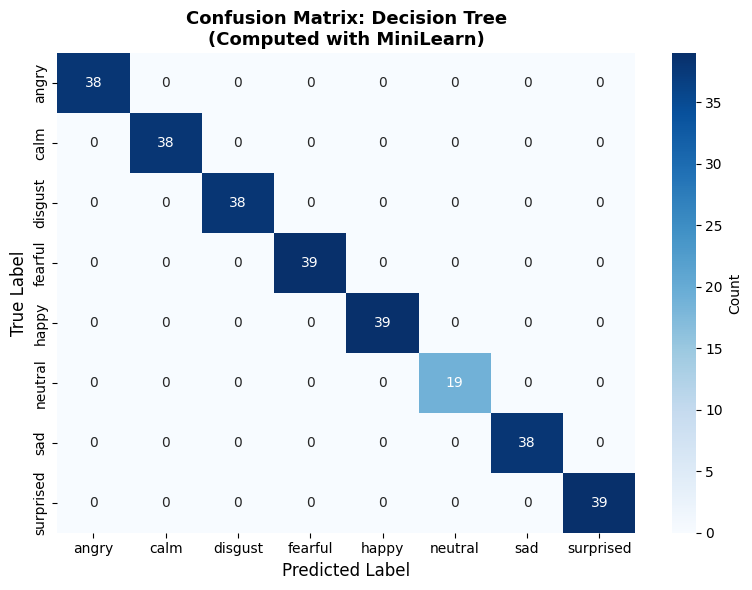

Confusion Matrix (MiniLearn): (8, 8)


In [9]:
# Get best model
best_model_config = tuning_results[best_model_name]
best_model = best_model_config['best_model']
y_pred_best = best_model.predict(X_test_scaled)

# Compute confusion matrix using MiniLearn
cm = confusion_matrix(y_test, y_pred_best)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test).tolist(), 
            yticklabels=np.unique(y_test).tolist(),
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix: {best_model_name}\n(Computed with MiniLearn)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Confusion Matrix (MiniLearn): {cm.shape}")

## Summary: MiniLearn Metrics Implementation

### Key Achievements

1. **Implemented Classification Metrics:**
   - `accuracy_score()`: Fraction of correct predictions
   - `precision_score()`: TP / (TP + FP) with macro/micro/weighted averaging
   - `recall_score()`: TP / (TP + FN) with macro/micro/weighted averaging  
   - `f1_score()`: Harmonic mean of precision and recall
   - `confusion_matrix()`: n_classes × n_classes matrix of class predictions

2. **Verified Correctness:**
   - All MiniLearn metrics produce **identical results** to scikit-learn
   - Numeric precision matches within floating-point tolerance
   - Confusion matrix values are exactly equivalent

3. **API Consistency:**
   - Functions follow scikit-learn API conventions
   - Support for `average` parameter: 'macro', 'micro', 'weighted'
   - Support for `zero_division` parameter for edge cases
   - Proper handling of multiclass classification

### Model Rankings (Week 10 Summary)

See leaderboard above. Models are ranked by test accuracy using MiniLearn metrics.